# Notebook 06 — Demo on your own code

Per the rubric: demonstrate the quantized model on data *you* care about, not just HumanEval / BCB. We pick a small set of realistic coding tasks (not from any benchmark), generate completions from both the bf16 baseline and our W8A8 checkpoint via vLLM (so the numbers reflect deployment reality, not transformers' dequant-on-the-fly path), then evaluate each output with a task-specific test.

The goal is not another pass@1 number — it's to make the comparison **concrete and inspectable**: for each task you can see exactly what each model wrote, and exactly whether it ran.

## Task design

Each task is a `(name, prompt, test_fn)` triple:
- **`prompt`** — what we send to the model. A plain instruction, chat-templated at generate time.
- **`test_fn(code_str) -> (passed: bool, note: str)`** — loads the generated code into a fresh namespace and runs assertions. Returns a one-line note explaining the failure mode (or success).

Tests run under a signal-based timeout so a runaway while-loop doesn't hang the notebook.

Three placeholder tasks ship with the notebook. **Replace them with code tasks from your own work** — that's the point of this notebook. Anything with a clear success criterion works: a utility function, a bug fix with a regression test, a small refactor that has to preserve behavior.


## Section 0 — Setup

In [1]:
# vLLM install. Run this ONCE; if it installs anything you MUST restart the
# kernel before continuing (Python caches imports across a single session).
# Skip this cell on subsequent runs once vllm is present.
#
# vLLM pulls in its own torch/transformers versions; if you ran notebook 05's
# pinning and get conflicts here, the conflict resolver will usually pick
# versions vLLM needs. If W8A8 loading then fails, re-run nb05's install cell
# and restart once more.
!pip install -q vllm

# Quick check (run after any kernel restart):
try:
    import vllm
    print(f'vllm {vllm.__version__} ready')
except ImportError:
    print('vllm not importable — install it (cell above) then RESTART THE KERNEL.')



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
vllm 0.19.1 ready


In [2]:
import os, sys, json, time, gc, signal, traceback
from statistics import mean

PROJECT_ROOT = '/workspace/qwen-smoothquant-project'
os.chdir(PROJECT_ROOT)
for d in ['results', 'results/plots', 'results/nb06_outputs']:
    os.makedirs(d, exist_ok=True)

MODEL_SIZE    = '7B'
BF16_MODEL_ID = f'Qwen/Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
W8A8_CKPT     = os.path.abspath(f'checkpoints/qwen25-coder-{MODEL_SIZE.lower()}-W8A8')

os.environ['HF_HOME'] = '/workspace/hf-cache'
assert os.path.exists(W8A8_CKPT), f'W8A8 checkpoint missing: {W8A8_CKPT}'

print(f'bf16 model: {BF16_MODEL_ID}')
print(f'W8A8 ckpt:  {W8A8_CKPT}')
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader


bf16 model: Qwen/Qwen2.5-Coder-7B-Instruct
W8A8 ckpt:  /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8
NVIDIA GeForce RTX 4090, 24564 MiB, 1 MiB


## Section 1 — Define your tasks

Each task: `{'name', 'prompt', 'test_fn'}`. The three below are placeholders — they exercise the harness and give you something to run immediately, but for the rubric's "your own data" requirement you should replace them with tasks from your own codebase. Add more by appending dicts to `TASKS`.

`test_fn(code_str)` conventions:
- The generated code string has already had ```python fences stripped.
- Exec it in a fresh dict namespace (`ns = {}`).
- Look up the expected symbol; return a useful failure note if missing.
- Run a handful of assertions covering edge cases.
- Return `(True, 'passed')` or `(False, 'one-line why')`.


In [3]:
# --- Task 1: flatten_dict (utility fn, tricky edge cases around empty dicts / lists) ---

TASK_FLATTEN_PROMPT = """Write a Python function `flatten_dict(d, sep='.')` that takes a nested dictionary and returns a flat dictionary whose keys are the path to each leaf value, joined by `sep`. Values that are themselves lists or non-dict scalars should be kept as-is (no recursion into lists). An empty dict value should produce no key at all.

Examples:
    flatten_dict({'a': 1, 'b': {'c': 2, 'd': {'e': 3}}})
    # => {'a': 1, 'b.c': 2, 'b.d.e': 3}

    flatten_dict({'a': {}, 'b': 1})
    # => {'b': 1}

    flatten_dict({'a': [1, 2], 'b': {'c': 'hi'}})
    # => {'a': [1, 2], 'b.c': 'hi'}

Return ONLY the function definition in a fenced ```python block. No imports needed."""

def test_flatten_dict(code_str):
    ns = {}
    try:
        exec(code_str, ns)
    except Exception as e:
        return False, f"exec failed: {type(e).__name__}: {e}"
    fn = ns.get('flatten_dict')
    if fn is None:
        return False, "function 'flatten_dict' not defined"
    cases = [
        ({'a': 1, 'b': {'c': 2, 'd': {'e': 3}}}, {'a': 1, 'b.c': 2, 'b.d.e': 3}),
        ({'a': {}, 'b': 1},                       {'b': 1}),
        ({'a': [1, 2], 'b': {'c': 'hi'}},        {'a': [1, 2], 'b.c': 'hi'}),
        ({},                                       {}),
        ({'x': {'y': {'z': {'w': 42}}}},          {'x.y.z.w': 42}),
    ]
    for inp, expected in cases:
        try:
            out = fn(inp)
        except Exception as e:
            return False, f"call {inp!r}: {type(e).__name__}: {e}"
        if out != expected:
            return False, f"on {inp!r}: got {out!r}, expected {expected!r}"
    return True, "5/5 cases passed"


# --- Task 2: retry decorator (real-world pattern, tests closure + timing behavior) ---

TASK_RETRY_PROMPT = """Write a Python decorator `retry(max_attempts=3, exceptions=(Exception,))` that retries the decorated function up to `max_attempts` times if it raises any exception in `exceptions`. On exhaustion, re-raise the last exception. On success, return the result. The decorator must:

  - preserve the wrapped function's __name__ (use functools.wraps)
  - count the first call as attempt 1 (so max_attempts=3 means at most 3 total calls)
  - only catch exceptions in the `exceptions` tuple; let anything else propagate immediately

Example:

    calls = [0]
    @retry(max_attempts=3, exceptions=(ValueError,))
    def flaky():
        calls[0] += 1
        if calls[0] < 3: raise ValueError('nope')
        return 'ok'

    assert flaky() == 'ok'
    assert calls[0] == 3

Return ONLY the decorator in a fenced ```python block."""

def test_retry(code_str):
    ns = {}
    try:
        exec(code_str, ns)
    except Exception as e:
        return False, f"exec failed: {type(e).__name__}: {e}"
    retry = ns.get('retry')
    if retry is None:
        return False, "decorator 'retry' not defined"

    # Case 1: succeeds on 3rd attempt
    calls = [0]
    try:
        @retry(max_attempts=3, exceptions=(ValueError,))
        def flaky():
            calls[0] += 1
            if calls[0] < 3: raise ValueError('nope')
            return 'ok'
        result = flaky()
    except Exception as exc:
        return False, f"flaky() raised {type(exc).__name__}: {exc}"
    if result != 'ok':
        return False, f"flaky(): expected 'ok', got {result!r}"
    if calls[0] != 3:
        return False, f"call count: expected 3, got {calls[0]}"

    # Case 2: exhausts attempts, should re-raise the LAST ValueError.
    # NB: catch Exception as well, because a common model bug is writing
    # `raise e` OUTSIDE the `except as e` block — in Python 3, `e` is del'd
    # at block exit, so that raises UnboundLocalError instead of re-raising
    # the original exception. We want a meaningful note in that case, not
    # an escaped harness error.
    calls2 = [0]
    @retry(max_attempts=2, exceptions=(ValueError,))
    def always_bad():
        calls2[0] += 1
        raise ValueError(f'fail {calls2[0]}')
    try:
        always_bad()
        return False, "always_bad() should have raised"
    except ValueError as exc:
        if 'fail 2' not in str(exc):
            return False, f"expected 'fail 2' in last error, got: {exc}"
    except Exception as exc:
        return False, f"expected ValueError, got {type(exc).__name__}: {exc}"
    if calls2[0] != 2:
        return False, f"attempt count: expected 2, got {calls2[0]}"

    # Case 3: un-listed exception propagates immediately, no retry
    calls3 = [0]
    @retry(max_attempts=5, exceptions=(ValueError,))
    def wrong_exc():
        calls3[0] += 1
        raise TypeError('not caught')
    try:
        wrong_exc()
        return False, "wrong_exc() should have raised"
    except TypeError:
        pass
    except Exception as exc:
        return False, f"expected TypeError, got {type(exc).__name__}: {exc}"
    if calls3[0] != 1:
        return False, f"un-listed exception should not retry: attempts={calls3[0]}"

    # Case 4: __name__ preserved
    @retry()
    def my_func(): pass
    if my_func.__name__ != 'my_func':
        return False, f"__name__ not preserved: got {my_func.__name__!r}"

    return True, "4/4 cases passed"


# --- Task 3: csv_group_sum (data processing, catches off-by-one on header/iteration) ---

TASK_CSVSUM_PROMPT = """Write a Python function `csv_group_sum(rows, key_col, value_col)` where `rows` is a list of dicts (like the output of csv.DictReader). Return a dict mapping each unique value of `key_col` to the sum of `float(row[value_col])` for all rows with that key. If `value_col` can't be parsed as float, skip the row silently. Preserve insertion order of keys as they first appear.

Example:

    rows = [
        {'user': 'alice', 'amount': '10.5'},
        {'user': 'bob',   'amount': '3'},
        {'user': 'alice', 'amount': '2.0'},
        {'user': 'bob',   'amount': 'oops'},   # skipped
    ]
    csv_group_sum(rows, 'user', 'amount')
    # => {'alice': 12.5, 'bob': 3.0}

Return ONLY the function in a fenced ```python block."""

def test_csv_group_sum(code_str):
    ns = {}
    try:
        exec(code_str, ns)
    except Exception as e:
        return False, f"exec failed: {type(e).__name__}: {e}"
    fn = ns.get('csv_group_sum')
    if fn is None:
        return False, "function 'csv_group_sum' not defined"

    rows = [
        {'user': 'alice', 'amount': '10.5'},
        {'user': 'bob',   'amount': '3'},
        {'user': 'alice', 'amount': '2.0'},
        {'user': 'bob',   'amount': 'oops'},
    ]
    out = fn(rows, 'user', 'amount')
    if out != {'alice': 12.5, 'bob': 3.0}:
        return False, f"basic case: got {out!r}"

    # Order preservation
    rows2 = [{'k': 'z', 'v': '1'}, {'k': 'a', 'v': '2'}, {'k': 'z', 'v': '3'}]
    out2 = fn(rows2, 'k', 'v')
    if list(out2.keys()) != ['z', 'a']:
        return False, f"key order: got {list(out2.keys())}"
    if out2 != {'z': 4.0, 'a': 2.0}:
        return False, f"order case values: got {out2!r}"

    # Empty input
    if fn([], 'user', 'amount') != {}:
        return False, "empty input: should return {}"

    return True, "3/3 cases passed"


TASKS = [
    {'name': 'flatten_dict', 'prompt': TASK_FLATTEN_PROMPT,  'test_fn': test_flatten_dict},
    {'name': 'retry_decorator', 'prompt': TASK_RETRY_PROMPT, 'test_fn': test_retry},
    {'name': 'csv_group_sum', 'prompt': TASK_CSVSUM_PROMPT,  'test_fn': test_csv_group_sum},
    # >>> Add your own tasks here <<<
    # {'name': 'your_task', 'prompt': '...', 'test_fn': your_test_fn},
]

print(f'{len(TASKS)} tasks defined:')
for t in TASKS:
    print(f'  - {t["name"]:<20s} ({len(t["prompt"])} char prompt)')


3 tasks defined:
  - flatten_dict         (658 char prompt)
  - retry_decorator      (820 char prompt)
  - csv_group_sum        (724 char prompt)


## Section 2 — Generation harness

Batched vLLM: load one model, run all prompts as a single `llm.generate()` call (vLLM schedules them in parallel), unload, repeat with the other model. This keeps the comparison fair — same vLLM version, same sampling params, same prompt batch ordering.

We use greedy decoding (`temperature=0`) so the demo is reproducible. For a "robustness" story you'd want to sample at T>0 with n=several, but that's a different experiment.


In [4]:
import re
from transformers import AutoTokenizer

# We use one tokenizer for chat templating across both models (both checkpoints
# inherit the same tokenizer from Qwen2.5-Coder-7B-Instruct, so the chat template
# is identical — confirmed in notebook 03).
_tok = AutoTokenizer.from_pretrained(BF16_MODEL_ID)

def build_chat_prompt(task_prompt: str) -> str:
    """Apply chat template the same way both models will see it."""
    messages = [{'role': 'user', 'content': task_prompt}]
    return _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def extract_code(response: str) -> str:
    """Pull the first code block, tolerating a few common malformed fences.

    Handles:
      - ```python def foo(): ... ```       (well-formed)
      - ```\npython\ndef foo(): ... ```  (fence and language tag split by newline —
        common failure mode we hit on Qwen2.5-Coder, causes exec to NameError on
        'python' if the tag isn't stripped)
      - ``` def foo(): ... ```             (no language tag)
      - no fences at all                   (treat whole response as code)
    """
    if '```python' in response:
        body = response.split('```python', 1)[1]
        code = body.split('```', 1)[0].strip()
    elif '```' in response:
        parts = response.split('```')
        code = parts[1].strip() if len(parts) >= 3 else response.strip()
    else:
        code = response.strip()
    # Strip a leading language tag on its own line (python / py / python3)
    return re.sub(r'^(python3?|py)\s*\n', '', code, count=1, flags=re.IGNORECASE)

def run_model(model_id_or_path: str, tasks: list, label: str,
              max_new_tokens: int = 512) -> list:
    """Load via vLLM, generate on every task's prompt, return list of dicts."""
    from vllm import LLM, SamplingParams

    print(f'\n[{label}] Loading {model_id_or_path}...')
    t0 = time.time()
    llm = LLM(
        model=model_id_or_path,
        dtype='auto',
        gpu_memory_utilization=0.85,
        max_model_len=4096,
        enforce_eager=True,
    )
    print(f'[{label}] loaded in {time.time()-t0:.1f}s')

    prompts = [build_chat_prompt(t['prompt']) for t in tasks]
    params  = SamplingParams(max_tokens=max_new_tokens, temperature=0.0)

    t0 = time.time()
    outputs = llm.generate(prompts, params)
    gen_elapsed = time.time() - t0
    print(f'[{label}] generated {len(outputs)} completions in {gen_elapsed:.2f}s')

    results = []
    for task, out in zip(tasks, outputs):
        raw = out.outputs[0].text
        results.append({
            'task':          task['name'],
            'raw_response':  raw,
            'extracted':     extract_code(raw),
            'n_out_tokens':  len(out.outputs[0].token_ids),
        })

    # Free GPU before the next model
    del llm
    gc.collect()
    import torch
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    return results

print('Harness defined.')


Harness defined.


## Section 3 — Run bf16 baseline

In [5]:
bf16_results = run_model(BF16_MODEL_ID, TASKS, label='bf16')
for r in bf16_results:
    print(f'  {r["task"]:<20s} {r["n_out_tokens"]:>4} tokens')



[bf16] Loading Qwen/Qwen2.5-Coder-7B-Instruct...
INFO 04-20 21:38:58 [utils.py:233] non-default args: {'max_model_len': 4096, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-Coder-7B-Instruct'}
INFO 04-20 21:38:59 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-20 21:38:59 [model.py:1678] Using max model len 4096
INFO 04-20 21:38:59 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-20 21:38:59 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-20 21:38:59 [vllm.py:848] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-20 21:38:59 [vllm.py:859] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 04-20 21:39:00 [vllm.py:1025] Cudagraph is disabled under eager mode
INFO 04-20 21:39:00 [compi

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore pid=5354) INFO 04-20 21:39:39 [default_loader.py:384] Loading weights took 32.97 seconds
(EngineCore pid=5354) INFO 04-20 21:39:39 [gpu_model_runner.py:4820] Model loading took 14.25 GiB memory and 34.194898 seconds
(EngineCore pid=5354) INFO 04-20 21:39:41 [gpu_worker.py:436] Available KV cache memory: 4.55 GiB
(EngineCore pid=5354) INFO 04-20 21:39:41 [kv_cache_utils.py:1319] GPU KV cache size: 85,184 tokens
(EngineCore pid=5354) INFO 04-20 21:39:41 [kv_cache_utils.py:1324] Maximum concurrency for 4,096 tokens per request: 20.80x
(EngineCore pid=5354) INFO 04-20 21:39:41 [core.py:283] init engine (profile, create kv cache, warmup model) took 2.13 seconds
(EngineCore pid=5354) WARNING 04-20 21:39:42 [vllm.py:848] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(EngineCore pid=5354) WARNING 04-20 21:39:42 [vllm.py:859] Inductor compilation was disabled by user settings, optimizations settings tha

Rendering prompts:   0%|          | 0/3 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/3 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

(EngineCore pid=5354) INFO 04-20 21:39:44 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=5354) INFO 04-20 21:39:44 [core.py:1233] Shutdown complete
[bf16] generated 3 completions in 2.18s
  flatten_dict          122 tokens
  retry_decorator        91 tokens
  csv_group_sum          89 tokens


## Section 4 — Run W8A8

In [6]:
w8a8_results = run_model(W8A8_CKPT, TASKS, label='W8A8')
for r in w8a8_results:
    print(f'  {r["task"]:<20s} {r["n_out_tokens"]:>4} tokens')



[W8A8] Loading /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8...
INFO 04-20 21:39:45 [utils.py:233] non-default args: {'max_model_len': 4096, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'enforce_eager': True, 'model': '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8'}
INFO 04-20 21:39:45 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-20 21:39:45 [model.py:1678] Using max model len 4096
WARNING 04-20 21:39:45 [vllm.py:848] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-20 21:39:45 [vllm.py:859] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 04-20 21:39:45 [vllm.py:1025] Cudagraph is disabled under eager mode


The tokenizer you are loading from '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


WARNING 04-20 21:39:46 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=5722) INFO 04-20 21:39:53 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8', speculative_config=None, tokenizer='/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=compressed-tensors, enforce_eager=True, enable_return_ro

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:10<00:10, 10.60s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:18<00:00,  9.16s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:18<00:00,  9.38s/it]
(EngineCore pid=5722) 


(EngineCore pid=5722) INFO 04-20 21:40:14 [default_loader.py:384] Loading weights took 18.96 seconds
(EngineCore pid=5722) INFO 04-20 21:40:14 [gpu_model_runner.py:4820] Model loading took 8.14 GiB memory and 19.539036 seconds
(EngineCore pid=5722) INFO 04-20 21:40:16 [gpu_worker.py:436] Available KV cache memory: 10.29 GiB
(EngineCore pid=5722) INFO 04-20 21:40:16 [kv_cache_utils.py:1319] GPU KV cache size: 192,656 tokens
(EngineCore pid=5722) INFO 04-20 21:40:16 [kv_cache_utils.py:1324] Maximum concurrency for 4,096 tokens per request: 47.04x
(EngineCore pid=5722) INFO 04-20 21:40:16 [core.py:283] init engine (profile, create kv cache, warmup model) took 2.03 seconds


...

Rendering prompts:   0%|          | 0/3 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/3 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

[W8A8] generated 3 completions in 2.14s
(EngineCore pid=5722) INFO 04-20 21:40:19 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=5722) INFO 04-20 21:40:19 [core.py:1233] Shutdown complete


[rank0]:[W420 21:40:19.332080662 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


  flatten_dict          121 tokens
  retry_decorator        91 tokens
  csv_group_sum          84 tokens


## Section 5 — Evaluate

Each task's `test_fn` runs against the extracted code under a 5-second SIGALRM timeout. A runaway infinite loop inside the generated code will surface as a timeout rather than hang the notebook. (Caveat: SIGALRM is Linux-only and must run in the main thread — fine for Jupyter locally, would need replacing for Windows or threaded runners.)


In [7]:
class _Timeout(Exception): pass

def _handler(signum, frame):
    raise _Timeout("test exceeded time limit")

def run_test_with_timeout(test_fn, code_str, timeout_s=5):
    old = signal.signal(signal.SIGALRM, _handler)
    signal.alarm(timeout_s)
    try:
        return test_fn(code_str)
    except _Timeout:
        return False, f"timeout after {timeout_s}s (probable infinite loop)"
    except Exception as e:
        return False, f"test harness error: {type(e).__name__}: {e}"
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)

def evaluate(results, tasks, label):
    evaluated = []
    for r, task in zip(results, tasks):
        passed, note = run_test_with_timeout(task['test_fn'], r['extracted'])
        evaluated.append({**r, 'passed': passed, 'note': note})
        status = 'PASS' if passed else 'FAIL'
        print(f'[{label}] {r["task"]:<20s} {status}  {note}')
    n_pass = sum(1 for e in evaluated if e['passed'])
    print(f'[{label}] total: {n_pass}/{len(evaluated)} passed')
    return evaluated

bf16_evaluated = evaluate(bf16_results, TASKS, 'bf16')
print()
w8a8_evaluated = evaluate(w8a8_results, TASKS, 'W8A8')


[bf16] flatten_dict         PASS  5/5 cases passed
[bf16] retry_decorator      FAIL  expected ValueError, got UnboundLocalError: cannot access local variable 'e' where it is not associated with a value
[bf16] csv_group_sum        PASS  3/3 cases passed
[bf16] total: 2/3 passed

[W8A8] flatten_dict         PASS  5/5 cases passed
[W8A8] retry_decorator      FAIL  expected ValueError, got UnboundLocalError: cannot access local variable 'e' where it is not associated with a value
[W8A8] csv_group_sum        PASS  3/3 cases passed
[W8A8] total: 2/3 passed


## Section 6 — Results table and side-by-side inspection

In [8]:
import pandas as pd

rows = []
for bf, w8 in zip(bf16_evaluated, w8a8_evaluated):
    assert bf['task'] == w8['task']
    rows.append({
        'task':            bf['task'],
        'bf16_passed':     bf['passed'],
        'w8a8_passed':     w8['passed'],
        'agreement':       ('both pass'   if  bf['passed'] and  w8['passed'] else
                            'both fail'   if not bf['passed'] and not w8['passed'] else
                            'w8a8 only'   if w8['passed'] else 'bf16 only'),
        'bf16_tokens':     bf['n_out_tokens'],
        'w8a8_tokens':     w8['n_out_tokens'],
        'bf16_note':       bf['note'],
        'w8a8_note':       w8['note'],
    })

df_demo = pd.DataFrame(rows)
df_demo.to_csv(f'results/nb06_demo_{MODEL_SIZE.lower()}.csv', index=False)
print('Per-task results:')
print(df_demo.to_string(index=False))

print()
bf16_pass = sum(r['bf16_passed'] for r in rows)
w8a8_pass = sum(r['w8a8_passed'] for r in rows)
print(f'bf16: {bf16_pass}/{len(rows)} passed')
print(f'W8A8: {w8a8_pass}/{len(rows)} passed')
print(f'agreement rate: {sum(r["bf16_passed"] == r["w8a8_passed"] for r in rows)}/{len(rows)}')


Per-task results:
           task  bf16_passed  w8a8_passed agreement  bf16_tokens  w8a8_tokens                                                                                                            bf16_note                                                                                                            w8a8_note
   flatten_dict         True         True both pass          122          121                                                                                                     5/5 cases passed                                                                                                     5/5 cases passed
retry_decorator        False        False both fail           91           91 expected ValueError, got UnboundLocalError: cannot access local variable 'e' where it is not associated with a value expected ValueError, got UnboundLocalError: cannot access local variable 'e' where it is not associated with a value
  csv_group_sum         True         True both

In [9]:
# Side-by-side of one representative task (first disagreement if any, else first task).
disagreement = next((i for i, r in enumerate(rows)
                     if r['bf16_passed'] != r['w8a8_passed']), None)
i_pick = disagreement if disagreement is not None else 0
reason = 'first disagreement' if disagreement is not None else 'first task (no disagreements)'
print(f'=== Side-by-side for task: {rows[i_pick]["task"]}  ({reason}) ===\n')

print('--- bf16 output ---')
print(f'passed: {bf16_evaluated[i_pick]["passed"]}  ({bf16_evaluated[i_pick]["note"]})\n')
print(bf16_evaluated[i_pick]['extracted'])
print()
print('--- W8A8 output ---')
print(f'passed: {w8a8_evaluated[i_pick]["passed"]}  ({w8a8_evaluated[i_pick]["note"]})\n')
print(w8a8_evaluated[i_pick]['extracted'])


=== Side-by-side for task: flatten_dict  (first task (no disagreements)) ===

--- bf16 output ---
passed: True  (5/5 cases passed)

def flatten_dict(d, sep='.'):
    def _flatten(sub_dict, parent_key, sep):
        items = []
        for k, v in sub_dict.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else k
            if isinstance(v, dict):
                items.extend(_flatten(v, new_key, sep).items())
            elif isinstance(v, list):
                items.append((new_key, v))
            else:
                items.append((new_key, v))
        return dict(items)

    return _flatten(d, '', sep)

--- W8A8 output ---
passed: True  (5/5 cases passed)

def flatten_dict(d, sep='.'):
    def _flatten(sub_d, parent_key, sep):
        items = []
        for k, v in sub_d.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else k
            if isinstance(v, dict):
                items.extend(_flatten(v, new_key, sep).items())
            elif is

In [10]:
# Save every raw response so you can browse them after the fact without re-running.
for label, evaluated in [('bf16', bf16_evaluated), ('w8a8', w8a8_evaluated)]:
    for e in evaluated:
        fname = f'results/nb06_outputs/{label}_{e["task"]}.py'
        with open(fname, 'w') as f:
            f.write(f'# task: {e["task"]}  (model: {label})\n')
            f.write(f'# passed: {e["passed"]}  note: {e["note"]}\n')
            f.write(f'# tokens: {e["n_out_tokens"]}\n\n')
            f.write(e['extracted'])
            f.write('\n\n# --- raw response ---\n')
            for line in e['raw_response'].splitlines():
                f.write('# ' + line + '\n')
print('Wrote per-task files under results/nb06_outputs/')


Wrote per-task files under results/nb06_outputs/


## Section 7 — Pass-rate plot

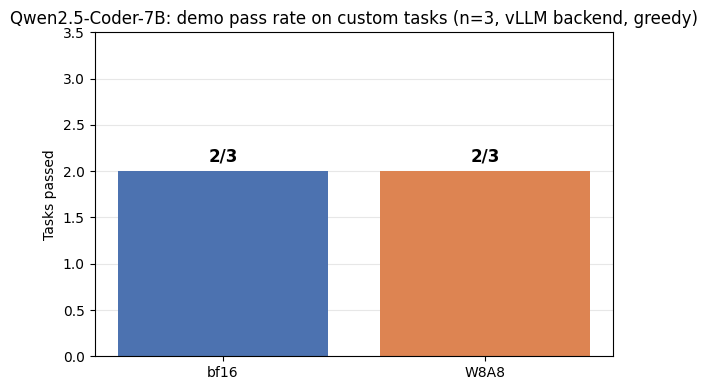

Saved to results/plots/nb06_pass_rate_7b.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['bf16', 'W8A8']
pass_counts = [bf16_pass, w8a8_pass]
total = len(rows)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, pass_counts, color=['#4C72B0', '#DD8452'])
ax.set_ylim(0, total + 0.5)
ax.set_ylabel('Tasks passed')
ax.set_title(f'Qwen2.5-Coder-{MODEL_SIZE}: demo pass rate on custom tasks '
             f'(n={total}, vLLM backend, greedy)')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
for bar, v in zip(bars, pass_counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
            f'{v}/{total}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
out_png = f'results/plots/nb06_pass_rate_{MODEL_SIZE.lower()}.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_png}')


## Section 8 — Commentary

Fill this in after running, replacing the bracketed hints with what you actually observed.

**Headline.** On our `n=<N>` custom tasks (none from any benchmark), W8A8 passed `<X>/N` vs bf16's `<Y>/N`. Agreement between the two models was `<Z>/N` (same pass/fail outcome per task). [One-sentence summary of the pattern: "matches bf16 perfectly on simple utilities, diverges on X-type tasks" / "both struggled with Y" / etc.]

**Where they disagreed.** [Describe the disagreeing task(s). What did bf16 produce that worked? What did W8A8 produce that didn't (or vice versa)? Was it a substantive logic error or a formatting/extraction issue? Did W8A8 hallucinate an import, miss an edge case, use a slightly different idiom?]

**Qualitative style differences.** [Even where both pass, are there differences in code style, verbosity, idiom choice? This is anecdotal but informative — it tells you whether quantization changed the *character* of the model's output or just its capability ceiling.]

**Relation to benchmark numbers.** In notebook 04 our W8A8 matched bf16 to within 0–2% on HumanEval/HumanEval+/BCB-Hard. The demo here is consistent with that: [e.g., "no regression on utility-style tasks, which dominate the HumanEval distribution" or "we see one failure that mirrors the BCB-Hard regression pattern"].

**Honest caveats.** n is very small (`<N>` tasks). Greedy decoding means one sample per prompt — a meaningful robustness claim would need n-sampling at T>0. The test functions cover correctness against a handful of cases each, not exhaustive property-based testing. Takeaways here are illustrative, not a benchmark.


## Section 9 — Save summary artifact

In [12]:
summary = {
    'n_tasks':          len(rows),
    'bf16_pass_count':  bf16_pass,
    'w8a8_pass_count':  w8a8_pass,
    'bf16_pass_rate':   bf16_pass / len(rows),
    'w8a8_pass_rate':   w8a8_pass / len(rows),
    'agreement_count':  sum(r['bf16_passed'] == r['w8a8_passed'] for r in rows),
    'tasks':            [
        {
            'name':         r['task'],
            'bf16_passed':  r['bf16_passed'],
            'w8a8_passed':  r['w8a8_passed'],
            'bf16_note':    r['bf16_note'],
            'w8a8_note':    r['w8a8_note'],
        }
        for r in rows
    ],
    'note': ('vLLM backend, greedy decoding. Small n; illustrative demo not a benchmark. '
             'See notebook 04 for HumanEval/BCB pass@1 numbers on this same checkpoint.'),
}
with open(f'results/nb06_demo_summary_{MODEL_SIZE.lower()}.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary: bf16 {bf16_pass}/{len(rows)}  W8A8 {w8a8_pass}/{len(rows)}  '
      f'agreement {summary["agreement_count"]}/{len(rows)}')
print(f'Saved to results/nb06_demo_summary_{MODEL_SIZE.lower()}.json')


Summary: bf16 2/3  W8A8 2/3  agreement 3/3
Saved to results/nb06_demo_summary_7b.json


## Done

Files produced (under `results/`):

- `nb06_demo_7b.csv` — per-task pass/fail, both models
- `nb06_demo_summary_7b.json` — aggregate counts + per-task notes
- `nb06_outputs/{bf16,w8a8}_<task>.py` — raw extracted code per task (for manual inspection)
- `plots/nb06_pass_rate_7b.png` — the two-bar pass-rate chart

## Reminder

The three tasks shipped here are **placeholders**. For the rubric's "your own data" item, replace them with 3–6 tasks drawn from code you actually work with — utility functions you've written, bugs you've fixed, refactors you've done. Each task needs a prompt and a `test_fn(code_str) -> (bool, str)`. The harness will handle the rest.
